# Run Multi-Processing VarDyn Experiment

'../configs/config_VarDyn_extGulfstream_allsat-alg_1month_Jan-Jun.py'

'../configs/config_VarDyn_extGulfstream_allsat-alg_1month_Jul-Dec.py'

## Libraries

In [4]:
from datetime import datetime
import matplotlib.pyplot as plt
import sys
sys.path.append('/home/nora/VarDyn/mapping')
from src import exp, state, inv, diag
from src.run_assimilation import prepare_process, compute_weights_map, plot_subdomains, run_assimilation_time_window, merge_time_windows_outputs

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

*** subwindow from 2019-01-01 00:00:00 to 2019-02-20 00:00:00 ***

*** subwindow from 2019-02-10 00:00:00 to 2019-04-01 00:00:00 ***

*** subwindow from 2019-03-22 00:00:00 to 2019-05-11 00:00:00 ***

*** subwindow from 2019-05-01 00:00:00 to 2019-06-20 00:00:00 ***

*** subwindow from 2019-06-10 00:00:00 to 2019-07-30 00:00:00 ***

*** subwindow from 2019-07-20 00:00:00 to 2019-09-08 00:00:00 ***

## Global parameters

In [5]:
path_config = '/home/nora/configs_VarDyn/multiwindows/config_VarDyn-QG_eNATL60-BLB002_GulfStream_multiwindows.py'

path_config_eq = '/home/nora/configs_VarDyn/multiwindows/config_VarDyn-QG_eNATL60-BLB002_GulfStream_multiwindows.py'

gpu_devices = ['1']

nprocs = 1

grid_type = 'GRID_CAR' # Type of grid. This is used to set the default values for the space window size and overlap  

space_window_size_proc_x = None # Space window size of one process in the x direction (degrees longitude) (Set to None for no split in space)

space_window_size_proc_y = None # Space window size of one process in the y direction (degrees latitude) (Set to None for no split in space)    

nx_proc = None # Number of grid points in the x direction for one process (only for GRID_CAR)

ny_proc = None # Number of grid points in the y direction for one process (only for GRID_CAR)

dx = dy = None # Grid spacing in km for one process (only for GRID_CAR)

space_overlap_x = None  # Absolute overlap in degrees (longitude) between successive space windows

space_overlap_y = None  # Absolute overlap in degrees (latitude) between successive space windows

time_window_size_proc = 50 # Time window size of one process (days). Set to None for no split in time.

time_overlap = 10  # Absolute overlap in days between successive time windows

JAX_mem_fraction = None

name_var_save = ['SSH_tot']

flag_init_from_previous = True

init_date = datetime(2009,7,11,0)    # datetime(2019,2,10,0) # datetime(2019,3,22,0)

final_date = datetime(2010,2,25,0)

flag_assim_restart = True

flag_assim = True

flag_merge_outputs = True

flag_diag = False

flag_overwrite_outputs = True

flag_test = False

flag_init_from_nadirs = False

name_exp_nadirs = '' # Name of the experiment for nadirs. This is used to use the output from the nadirs.

## Configuration file

In [6]:
config = exp.Exp(path_config)
config_eq = exp.Exp(path_config)

name_experiment: VarDyn-QG_eNATL60-BLB002_GulfStream_multiwindows
saveoutputs: True
name_exp_save: VarDyn-QG_eNATL60-BLB002_GulfStream_multiwindows
path_save: /data2/nora/Workdir/VarDyn/outputs/VarDyn-QG_eNATL60-BLB002_GulfStream_multiwindows
tmp_DA_path: /data2/nora/Workdir/VarDyn/scratch/VarDyn-QG_eNATL60-BLB002_GulfStream_multiwindows
init_date: 2009-07-11 00:00:00
final_date: 2010-02-25 00:00:00
assimilation_time_step: 6:00:00
saveoutput_time_step: 6:00:00
flag_plot: 0
write_obs: True
path_obs: /data2/nora/Workdir/VarDyn/obs
compute_obs: False
name_lon: lon
name_lat: lat
name_time: time
plot_time_step: 1 day, 0:00:00
time_obs_min: None
time_obs_max: None
lon_obs_min: None
lon_obs_max: None
lat_obs_min: None
lat_obs_max: None

name_experiment: VarDyn-QG_eNATL60-BLB002_GulfStream_multiwindows
saveoutputs: True
name_exp_save: VarDyn-QG_eNATL60-BLB002_GulfStream_multiwindows
path_save: /data2/nora/Workdir/VarDyn/outputs/VarDyn-QG_eNATL60-BLB002_GulfStream_multiwindows
tmp_DA_path: /dat

## State

super: GRID_GEO
lon_min: -65
lon_max: -55
lat_min: 33
lat_max: 43
dlon: 0.1
dlat: 0.1
name_init_mask: /data1/data/models/eNATL60/BLB002/coarsened/eNATL60-BLB002_coarse-5_rolling-20.nc
name_var_mask: {'lon': 'lon', 'lat': 'lat', 'var': 'ssh'}



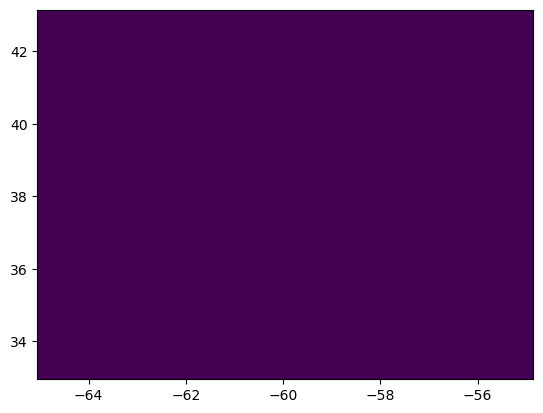

In [7]:
State = state.State(config)
plt.pcolormesh(State.lon,State.lat,State.mask)

## Prepare Assimilation

#### Create subwindows

In [8]:
list_processes, list_config, list_State, list_date_start, list_date_end, list_date_middle, list_lonlat =\
      prepare_process(config, config_eq, State, 
                    init_date, final_date,
                    grid_type=grid_type,
                    nx_proc=nx_proc, ny_proc=ny_proc, dx=dx, dy=dy,
                    time_window_size_proc=time_window_size_proc, space_window_size_proc_x=space_window_size_proc_x, space_window_size_proc_y=space_window_size_proc_y, 
                    time_overlap=time_overlap, space_overlap_x=space_overlap_x, space_overlap_y=space_overlap_y,
                    flag_init_from_previous=flag_init_from_previous, flag_init=flag_init_from_nadirs, flag_background=False,
                    flag_assim=flag_assim, flag_assim_restart=flag_assim_restart,
                    name_exp_init=name_exp_nadirs, name_exp_background=name_exp_nadirs,
                    gpu_devices=gpu_devices)

0 subwindow_2009-08-05/subwindow_-60_38
1 subwindow_2009-09-14/subwindow_-60_38
2 subwindow_2009-10-24/subwindow_-60_38
3 subwindow_2009-12-03/subwindow_-60_38
4 subwindow_2010-01-12/subwindow_-60_38
5 subwindow_2010-02-10/subwindow_-60_38


#### Compute weight maps

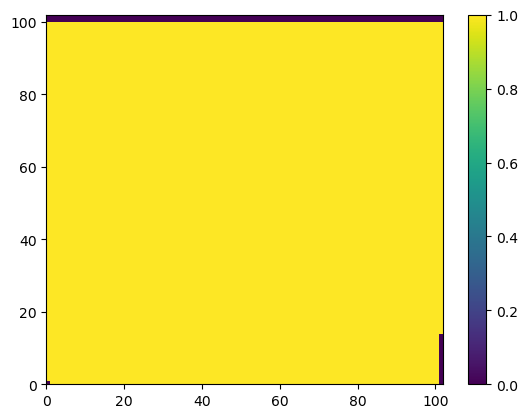

In [9]:
weights_space, weights_space_sum, interpolators = compute_weights_map(State, list_State)
plt.pcolormesh(weights_space_sum)
plt.colorbar()

#### Plot domains

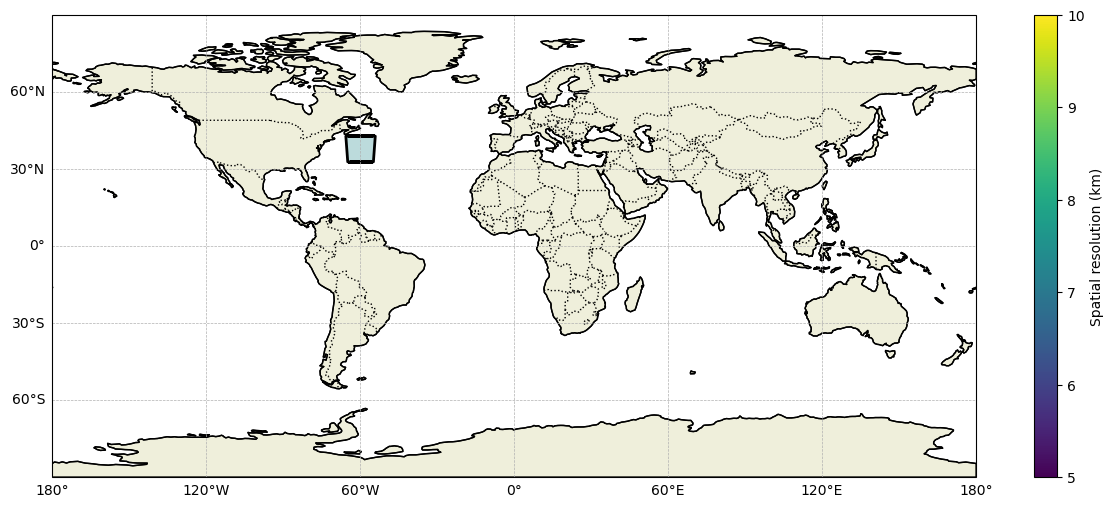

In [10]:
lonlat_grid = [(State.lon,State.lat) for State in list_State[0]]
plot_subdomains(lonlat_grid)

## Assimilation

In [11]:
idt = 0
idx = 0
if flag_test:

    State = list_State[idt][idx]
    plt.figure()
    plt.pcolormesh(State.lon, State.lat, State.mask)
    plt.show()

    list_config[idt][idx].EXP.flag_plot = 1
    list_config[idt][idx].INV.maxiter = 10
    list_State[idt][idx].flag_plot = 1

    inv.Inv_4Dvar(config=list_config[idt][idx], State=list_State[idt][idx], verbose=0, gpu_device=gpu_devices[0])
    list_config[idt][idx].EXP.flag_plot = config.EXP.flag_plot
    list_State[idt][idx].flag_plot = State.flag_plot
    list_config[idt][idx].INV.maxiter = config.INV.maxiter

In [12]:
idt = 1
idx = 0
if flag_test:

    State = list_State[idt][idx]
    plt.figure()
    plt.pcolormesh(State.lon, State.lat, State.mask)
    plt.show()

    list_config[idt][idx].EXP.flag_plot = 1
    list_config[idt][idx].INV.maxiter = 10
    list_State[idt][idx].flag_plot = 1

    inv.Inv_4Dvar(config=list_config[idt][idx], State=list_State[idt][idx], verbose=0, gpu_device=gpu_devices[0])
    list_config[idt][idx].EXP.flag_plot = config.EXP.flag_plot
    list_State[idt][idx].flag_plot = State.flag_plot
    list_config[idt][idx].INV.maxiter = config.INV.maxiter

In [13]:
for i, processes in enumerate(list_processes):
    print(f'*** subwindow from {list_date_start[i]} to {list_date_end[i]} ***')
    run_assimilation_time_window(config, list_date_start[i], list_date_middle[i], list_date_end[i], list_State[i], processes, 
                                 name_var_save=name_var_save,
                                 weights_space=weights_space,
                                 weights_space_sum=weights_space_sum,
                                 interpolators=interpolators,
                                 flag_assim=flag_assim, flag_merge_outputs=flag_merge_outputs, flag_diag=flag_diag, flag_overwrite_outputs=flag_overwrite_outputs,
                                 nprocs=nprocs)

*** subwindow from 2009-07-11 00:00:00 to 2009-08-30 00:00:00 ***
Run subprocesses
super: MOD_DIFF
name_var: {'SSH': 'ssh_barotrop'}
var_to_save: None
name_init_var: {}
dtmodel: 1800
Kdiffus: 0
SIC_mod: False
init_from_bc: False
dist_sponge_bc: None


super: MOD_QG1L_JAX
name_class: Qgm
name_var: {'SSH': 'ssh'}
name_init_var: {'SSH': 'ssh'}
dir_model: None
var_to_save: None
save_diagnosed_variables: False
save_params: False
upwind: 3
advect_pv: True
advect_tracer: False
dtmodel: 1800
cfl: 0.1
time_scheme: rk2
c0: 2.7
filec_aux: /home/nora/VarDyn/mapping/aux/aux_first_baroclinic_speed.nc
name_var_c: {'lon': 'lon', 'lat': 'lat', 'var': 'c1'}
cmin: 2.0
cmax: None
file_bathy_aux: None
name_var_bathy: {'lon': '', 'lat': '', 'var': ''}
bathy_ratio_max: None
solver: spectral
init_from_bc: True
dist_sponge_bc: None
Kdiffus: 150
Kdiffus_trac: None
bc_trac: OBC
forcing_tracer_from_bc: False
constant_c: True
constant_f: True
f0: None
tile_size: 32
tile_overlap: 16
path_mdt: None
name_var_mdt: Non

## Merge outputs

In [14]:
merge_time_windows_outputs(config, list_date_start, list_date_middle, list_date_end, time_overlap)

## Diagnostics

In [15]:
config.EXP.init_date = init_date
config.EXP.final_date = final_date

super: DIAG_OSSE
dir_output: /data2/nora/Workdir/VarDyn/diags/VarDyn-QG_eNATL60-BLB002_GulfStream_multiwindows
time_min: None
time_max: None
time_step: None
lon_min: None
lon_max: None
lat_min: None
lat_max: None
path_images2mp4: /data1/packages/climporn/ffmpeg/images2mp4.sh
name_ref: /data1/data/models/eNATL60/BLB002/degraded_20/*_SSH.nc
name_ref_time: time
name_ref_lon: lon
name_ref_lat: lat
name_ref_var: ssh
options_ref: {}
name_exp_time: None
name_exp_lon: None
name_exp_lat: None
name_exp_var: SSH_tot
exp_grid_type: None
compare_to_baseline: False
name_bas: /data2/nora/Workdir/VarDyn/outputs/VarDyn-QG_eNATL60-BLB002_GulfStream_float32/*.nc
name_bas_time: time
name_bas_lon: lon
name_bas_lat: lat
name_bas_var: ssh
name_mask: None
name_var_mask: {'lon': '', 'lat': '', 'var': ''}



/home/nora/VarDyn/mapping/src/diag.py:141: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  self.ref_dims = list(self.ref.dims.keys())


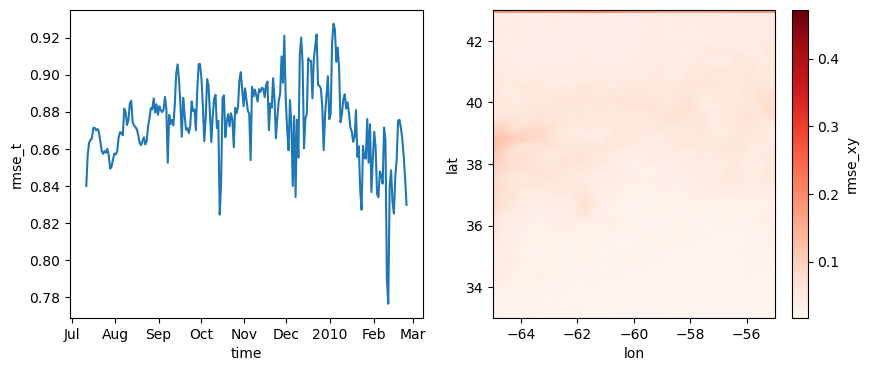

/home/nora/miniconda3/envs/massh_nora/lib/python3.13/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/home/nora/miniconda3/envs/massh_nora/lib/python3.13/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(


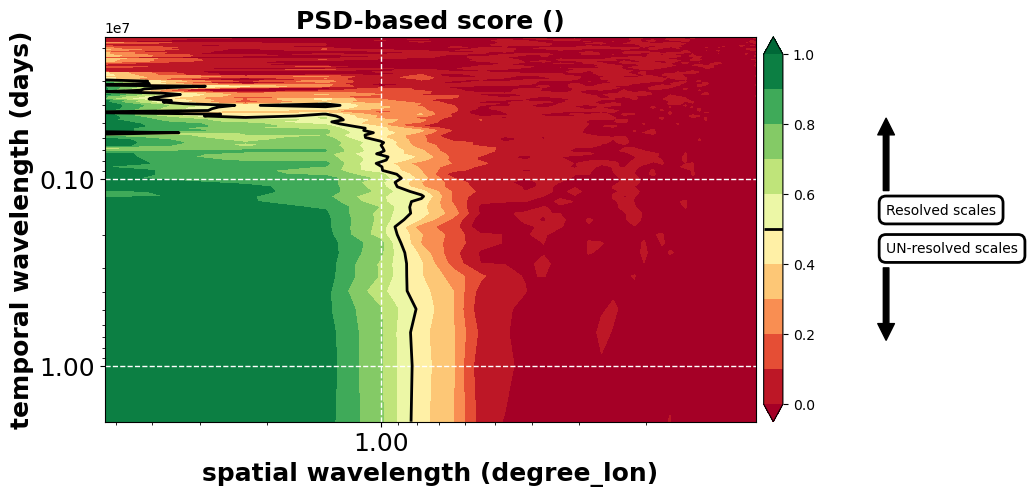

,Method,µ(RMSE),σ(RMSE),λx (degree),λt (days)
0,VarDyn-QG_eNATL60-BLB002_GulfStream_multiwindows,0.87,0.02,0.77,5.12


In [16]:
Diag = diag.Diag(config,State)
Diag.regrid_exp()
Diag.rmse_based_scores(plot=True)
Diag.psd_based_scores(plot=True)
Diag.Leaderboard()